In [ ]:
# =============================================
# Resolution de l'Equation Elliptique
# -d^2u/dx=f avec x dans ]0 ,1[, avec
# f(x) = sin(np.pi*x), et
# la condition a la limite u(0) = u(1) = 0
# ==============================================

In [1]:
# IMPORTATION DES LIBRAIRIES
# ==========================
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm

In [2]:
#%% MAILLAGE DU DOMAINE
# ==========================
NX = 10  # Nombre de points du maillage
x = np.linspace(0.0, 1, NX)  # Positions sur le domaine [0,1]
dx = 1 / (NX - 1)  # Pas de discretisation

In [3]:
# DEFINITION DE LA FONCTION SOURCE F
# ==================================
def func1(x):
    return np.sin(np.pi * x)  # Fonction source f(x)

f = np.vectorize(func1)

In [4]:
# DEFINITION DE LA SOLUTION EXACTE
# =================================
def func2(x):
    return np.sin(np.pi * x) / (np.pi**2)  # Solution exacte analytique

Uex = np.vectorize(func2)

In [5]:
#%% CALCUL DE LA SOLUTION DISCRETE
# ================================
def U_discret(x, NX, dx, f):
    U = np.zeros((NX,))  # Initialisation du vecteur solution
    U[0] = 0  # Condition limite u(0)
    U[-1] = 0  # Condition limite u(1)

    F = (dx**2) * f(x)  # Terme source discrét
    F = F[1 : NX - 1]  # Exclusion des points de bord

    val_diags = [-np.ones(NX - 2), 2 * np.ones(NX - 2), -np.ones(NX - 2)]  # Coefficients diagonaux
    positions = np.array([-1, 0, 1])  # Positions des diagonales
    A = sp.dia_matrix((val_diags, positions), shape=(NX - 2, NX - 2))  # Matrice de Laplacien

    Uint = spsolve(A, F)  # Resolution du systeme lineaire
    U[1 : NX - 1] = Uint  # Insertion des valeurs interieures

    return U

c:\Users\bmd tech\anaconda3\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


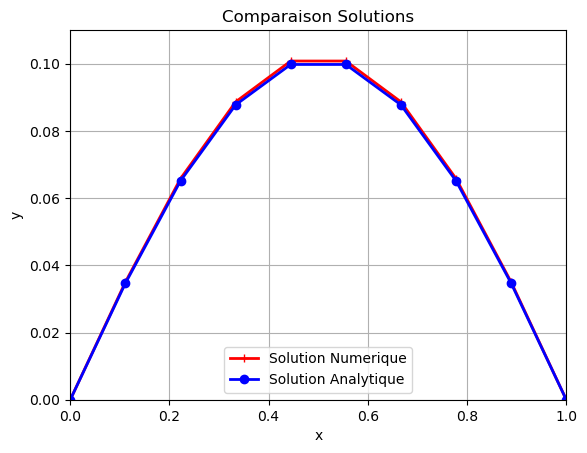

In [6]:
#%% AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
# =========================================================
U = U_discret(x, NX, dx, f)  # Solution numerique
Uexact = Uex(x)  # Solution exacte

fig, ax = plt.subplots(1)
ax.plot(x, U, "r-+", lw=2, label="Solution Numerique")  # Courbe solution numerique
ax.plot(x, Uexact, "b-o", lw=2, label="Solution Analytique")  # Courbe solution exacte
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim([0, 1])
ax.set_ylim([0, 0.11])
ax.set_title("Comparaison Solutions")
ax.legend()
ax.grid()
plt.show()

2.6090587013274157e-06 : NORME de l’erreur absolue
Ordre de Convergence en erreur Relative : 1.9756234059365518
Ordre de Convergence en erreur absolue : 1.974947010216945


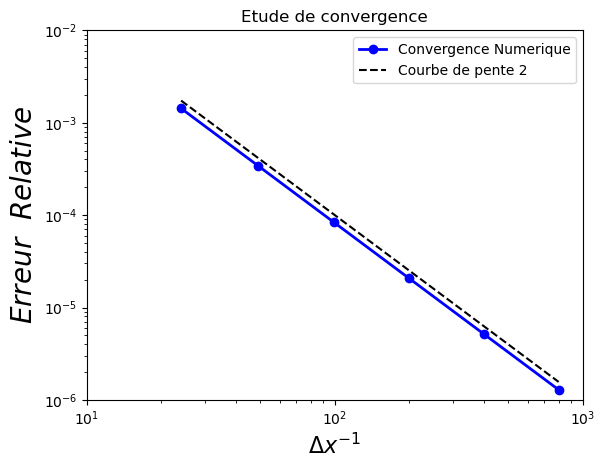

In [8]:
#%% ETUDE DE LA CONSISTENCE ET DE LA CONVERGENCE EN ESPACE DU SCHEMA
# ==================================================================
NX = np.array([25, 50, 100, 200, 400, 800])  # Differentes resolutions
NN = NX.size  # Nombre de tests
dx = 1 / (NX - 1)  # Pas pour chaque resolution

ERRABS = np.zeros(NN)  # Erreur absolue
ERRLAT = np.zeros(NN)  # Erreur relative

for k in range(NN):
    x = np.linspace(0.0, 1, NX[k])  # Nouvelle discretisation
    UC = U_discret(x, NX[k], dx[k], f)  # Solution numerique
    Uexact = Uex(x)  # Solution exacte

    # Calcul des erreurs
    ERRABS[k] = max(abs(UC - Uexact))  # Erreur absolue
    ERRLAT[k] = max(abs(UC - Uexact)) / max(abs(Uexact))  # Erreur relative

# Affichage des erreurs
print(norm((UC - Uexact)), ": NORME de l’erreur absolue")

# Calcul de l'ordre de convergence
P1 = np.log((ERRLAT[1] - ERRLAT[2]) / (ERRLAT[2] - ERRLAT[3])) / np.log(dx[0] / dx[1])
print("Ordre de Convergence en erreur Relative :", P1)

P2 = np.log((ERRABS[1] - ERRABS[2]) / (ERRABS[2] - ERRABS[3])) / np.log(dx[0] / dx[1])
print("Ordre de Convergence en erreur absolue :", P2)

# Tracé de la convergence
fig, ax = plt.subplots(1)
ax.loglog(dx**-1, ERRLAT, "b-o", lw=2, label="Convergence Numerique")
ax.loglog(dx**-1, 1 * dx**2, "--k", label="Courbe de pente 2")
ax.set_xlabel("$\\Delta x^{-1}$", fontsize=16)
ax.set_ylabel("$Erreur ~~ Relative$", fontsize=20)
ax.set_xlim([10**1, 10**3])
ax.set_ylim([10**-6, 10**-2])
ax.set_title("Etude de convergence")
ax.legend()
plt.show()